# 1. Import libraries

*****This ipynb file is used to visualize the dataset used in the project, to be specific, sarcasm detection dataset and sentiment analysis dataset used in multitask learning and emotion classification dataset used in emotion classification. Cause in the project, I have came up with a new idea when doing the emotion classification which is embed the sentiment label into the word embedding, in order to improve the accuracy of the model, hence, a proper dataset is neccessary for the task. Because of this, I made use of a wide used dataset called "emotions", and in order to fit in the task, some operations will need to be conducted, which has been listed in the following file in detail.*****

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

try:
    from wordcloud import WordCloud
except ModuleNotFoundError:
    WordCloud = None

PLOT_BACKGROUND = '#e8f3fb'
AXES_BACKGROUND = '#f8fbfe'
GRID_COLOR = '#c9dce8'
TEXT_COLOR = '#1f3344'
BAR_EDGE_COLOR = '#ffffff'
DISTRIBUTION_PALETTE = ['#2f6fed', '#f28e2b', '#35b779', '#d94b4b', '#8e63ce', '#b86b1f']


def make_autopct(values, show_count=False):
    def autopct(pct):
        total = sum(values)
        value = int(round(pct * total / 100.0))
        if show_count:
            return f'{pct:.1f}%\n({value:,})'
        return f'{pct:.1f}%'
    return autopct


def style_bar_axis(ax, max_count):
    ax.set_facecolor(AXES_BACKGROUND)
    ax.grid(axis='y', color=GRID_COLOR, linewidth=1.0, alpha=0.85)
    ax.grid(axis='x', visible=False)
    ax.set_axisbelow(True)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#9fb7c8')

    ax.tick_params(axis='x', labelsize=10, colors=TEXT_COLOR, rotation=20)
    ax.tick_params(axis='y', labelsize=10, colors=TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.xaxis.label.set_color(TEXT_COLOR)

    if max_count > 0:
        ax.set_ylim(0, max_count * 1.18)

    for patch in ax.patches:
        value = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + max_count * 0.025 if max_count > 0 else value,
            f'{int(value):,}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='semibold',
            color=TEXT_COLOR
        )


def plot_distribution(count, left_title, right_title, x_label, y_label='Count', subtitle=None, show_pie_counts=False):
    count = count.astype(int)
    palette = DISTRIBUTION_PALETTE[:len(count)]

    sns.set_theme(
        style='whitegrid',
        rc={
            'axes.facecolor': AXES_BACKGROUND,
            'figure.facecolor': PLOT_BACKGROUND,
            'grid.color': GRID_COLOR,
            'axes.edgecolor': '#9fb7c8',
            'text.color': TEXT_COLOR,
            'axes.labelcolor': TEXT_COLOR,
            'xtick.color': TEXT_COLOR,
            'ytick.color': TEXT_COLOR,
            'font.family': 'DejaVu Sans'
        }
    )

    fig, axs = plt.subplots(1, 2, figsize=(12.5, 5.8), facecolor=PLOT_BACKGROUND)

    wedges, texts, autotexts = axs[0].pie(
        count.values,
        labels=count.index,
        autopct=make_autopct(count.values, show_count=show_pie_counts),
        startangle=135,
        colors=palette,
        wedgeprops={'linewidth': 1.4, 'edgecolor': BAR_EDGE_COLOR},
        textprops={'fontsize': 10, 'color': TEXT_COLOR}
    )
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_fontweight('semibold')
        autotext.set_color('#ffffff')

    axs[0].set_title(left_title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=14)
    axs[0].set_facecolor(PLOT_BACKGROUND)

    plot_df = pd.DataFrame({x_label: count.index, y_label: count.values})
    bar_ax = sns.barplot(
        data=plot_df,
        x=x_label,
        y=y_label,
        hue=x_label,
        ax=axs[1],
        palette=palette,
        legend=False,
        edgecolor=BAR_EDGE_COLOR,
        linewidth=1.2
    )

    axs[1].set_title(right_title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=14)
    axs[1].set_xlabel(x_label, fontsize=10, labelpad=10)
    axs[1].set_ylabel(y_label, fontsize=10, labelpad=10)
    style_bar_axis(axs[1], count.max())

    if subtitle:
        fig.text(0.5, 0.015, subtitle, ha='center', fontsize=10, color='#3d5a70')
        plt.tight_layout(rect=[0, 0.04, 1, 1])
    else:
        plt.tight_layout()

    plt.show()

# 2. Read dataset and visualization
In the task, two separate datasets are needed for multitask learning (including sentiment analysis and sarcasm detection) and emotion classification. In the following file, ec represents emotion classification and sd represents sarcasm detection.

In [2]:
# read emotion classification dataset
ec_dataset = pd.read_csv('text.csv')
# read sarcamsm detection dataset
sd_dataset = pd.read_csv('sarcasm_dataset.csv')
# read sentiment analysis dataset
# in order to compare the result gotten from multitask learning, I use this dataset which have been used by other authors, hence can provide a better result comparison
sa_dataset = pd.read_csv("Reddit_Data.csv")

## (a) Emotion Classification dataset

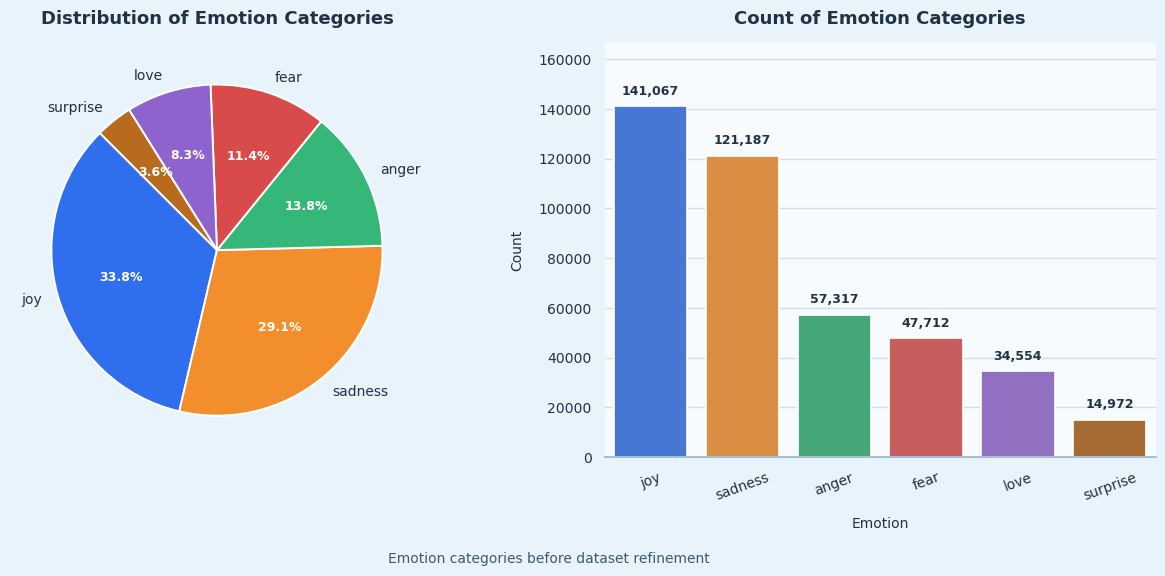

In [3]:
vis_dataset = pd.read_csv('text.csv')
emotion_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

vis_dataset['label_name'] = vis_dataset['label'].map(emotion_map)
count = vis_dataset['label_name'].value_counts()

plot_distribution(
    count,
    left_title='Distribution of Emotion Categories',
    right_title='Count of Emotion Categories',
    x_label='Emotion',
    subtitle='Emotion categories before dataset refinement'
)

***It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label, and since there is no neutral label, I tend to copy similar context with neutral label into this dataset.It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label, and since there is no neutral label, I tend to copy similar context with neutral label into this dataset.It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label, and since there is no neutral label, I tend to copy similar context with neutral label into this dataset.It is clear that the dataset is quite unbalanced.Label 'surprise' only contains less than 20k data. In order to get each data its sentiment label, I need to classify data into sentiment labels. It is clear that, joy, love are positive, and sadness, anger, fear are negative, however, it is hard to get the sentiment from surprise, since it can be either surprise in positive or negative way, hence I tend to delete the 'surprise' label.***

***Since there is no neutral label, and for current dataset which has both sentiment and emotion labels, most of them at least have certain kinds of shortcomings, such as lack the number of data, labels unclear, dataset unbalanced, lack of neutral, hence I tend to do some modifications on several datasets to make it a balanced dataset including both sentiment and emotions labels for tasks similar my project, and I will test the method performance on the dataset. In the comparison part, I will test performance on balanced (dataset modified by me) and unbalanced dataset ('emotions' dataset with no 'surprise' label) respectively, which can have a comprehensive analysis on the method proposed.***

## (b) Sarcasm Detection dataset

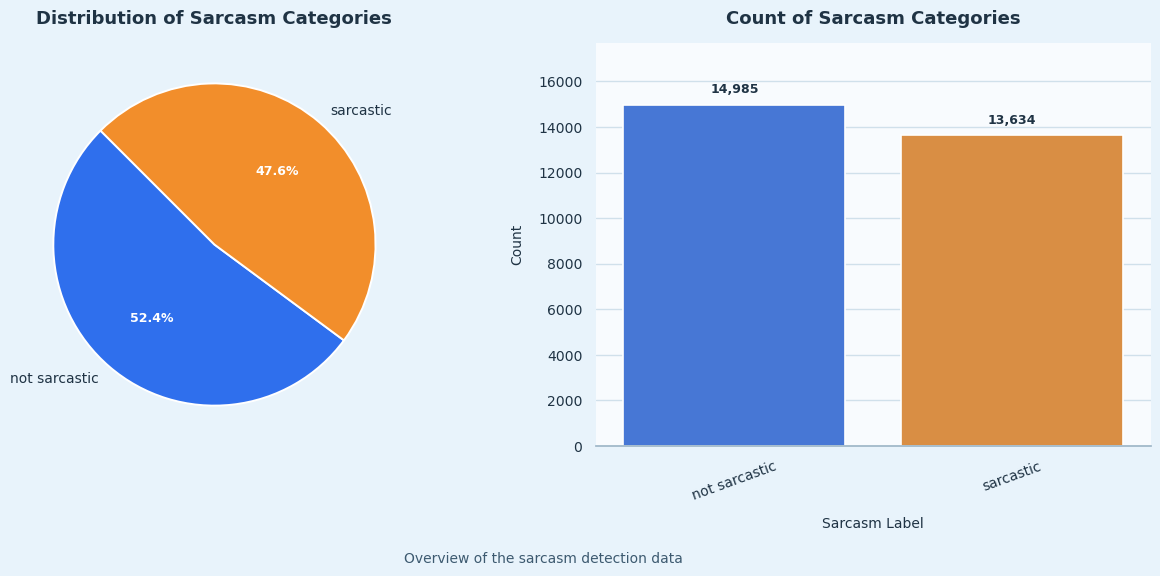

In [4]:
vis_dataset = pd.read_csv('sarcasm_dataset.csv')

sarcasm_map = {
    0: 'not sarcastic',
    1: 'sarcastic'
}
vis_dataset['sarcasm_label'] = vis_dataset['is_sarcastic'].map(sarcasm_map)
count = vis_dataset['sarcasm_label'].value_counts()

plot_distribution(
    count,
    left_title='Distribution of Sarcasm Categories',
    right_title='Count of Sarcasm Categories',
    x_label='Sarcasm Label',
    subtitle='Overview of the sarcasm detection data'
)

*It is slightly unbalanced, however, in order to **Control Variable** to compare with other work, the dataset cannot be changed.*

## (c) Sentiment Analysis dataset

Sentiment count in Reddit_Data.csv:
sentiment_name
negative     8277
neutral     13142
positive    15830
Name: count, dtype: int64


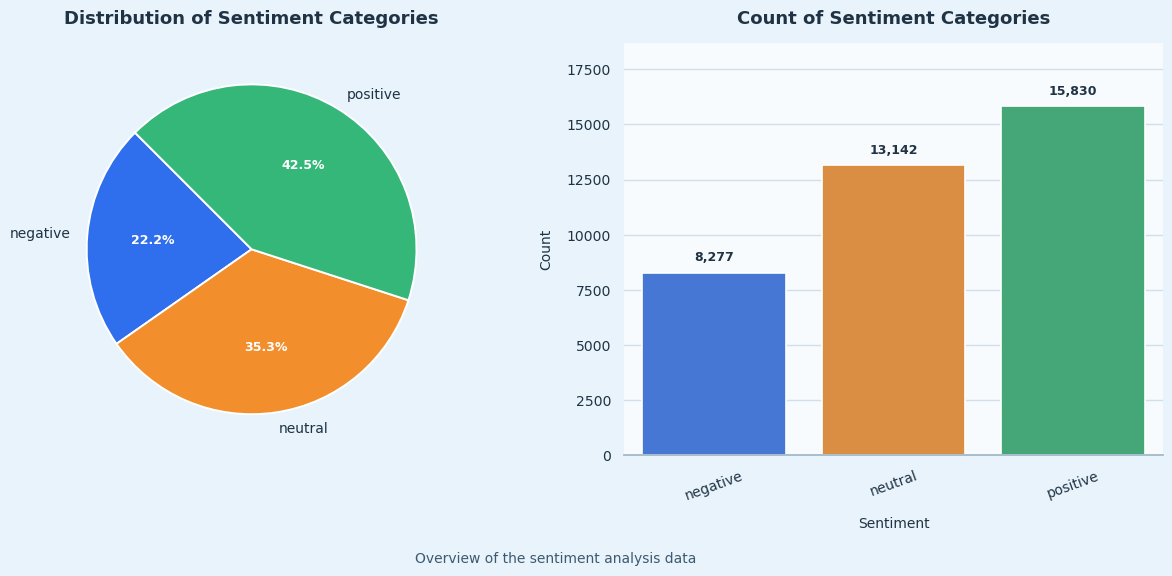

In [5]:
vis_dataset = pd.read_csv('Reddit_Data.csv')

sentiment_map = {
    -1: 'negative',
     0: 'neutral',
     1: 'positive'
}
sentiment_order = ['negative', 'neutral', 'positive']

vis_dataset['category_numeric'] = pd.to_numeric(vis_dataset['category'], errors='coerce')
vis_dataset['sentiment_name'] = vis_dataset['category_numeric'].map(sentiment_map)

unmapped = vis_dataset.loc[vis_dataset['sentiment_name'].isna(), 'category'].value_counts(dropna=False)
if len(unmapped) > 0:
    print('Unmapped category values:')
    print(unmapped)

count = vis_dataset['sentiment_name'].value_counts().reindex(sentiment_order, fill_value=0)

print('Sentiment count in Reddit_Data.csv:')
print(count)

plot_distribution(
    count,
    left_title='Distribution of Sentiment Categories',
    right_title='Count of Sentiment Categories',
    x_label='Sentiment',
    subtitle='Overview of the sentiment analysis data'
)

*It is also slightly unbalanced, however, in order to **Control Variable** to compare with other work, the dataset cannot be changed.*

# 3. Dataset refining

***In this part, I will drop the data with label = 5, which is surprise. Besides, I will add one more column which is sentiment, and set sentiment = 0 when 'label' = 0, 3, 4, which are sadness, anger and fear respectively, they all represent the negative feeling, and for 1, 2, they will be labeled as 1 which is positive. Eventually, I will save them and split them into 80% training dataset and 20% testing dataset for training and evaluation respectively.***

In [6]:
# read emotion classification dataset
ec_dataset = pd.read_csv('text.csv')
# Drop data with 'label' = 5
ec_dataset = ec_dataset[ec_dataset['label'] != 5][['text', 'label']]

In [7]:
# visualize data
print(ec_dataset.head())
print(ec_dataset['label'].value_counts())

                                                text  label
0      i just feel really helpless and heavy hearted      4
1  ive enjoyed being able to slouch about relax a...      0
2  i gave up my internship with the dmrg and am f...      4
3                         i dont know i feel so lost      0
4  i am a kindergarten teacher and i am thoroughl...      4
label
1    141067
0    121187
3     57317
4     47712
2     34554
Name: count, dtype: int64


    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',

In [8]:
# Add sentiment
ec_dataset['sentiment'] = ec_dataset['label'].apply(lambda x: 0 if x in [0, 3, 4] else 1)

In [9]:
print(ec_dataset.head())
print(ec_dataset['sentiment'].value_counts())

                                                text  label  sentiment
0      i just feel really helpless and heavy hearted      4          0
1  ive enjoyed being able to slouch about relax a...      0          0
2  i gave up my internship with the dmrg and am f...      4          0
3                         i dont know i feel so lost      0          0
4  i am a kindergarten teacher and i am thoroughl...      4          0
sentiment
0    226216
1    175621
Name: count, dtype: int64


In [10]:
# Since the number of data is too much, hence require a powerful machine to process, hence I reduce the number of data to 50%
print("Original dataset distribution:")
print(ec_dataset['label'].value_counts())

# split the data by 'label'
reduced_dataset = ec_dataset.groupby('label', group_keys=False).apply(
    lambda x: x.sample(frac=0.5, random_state=42)
).reset_index(drop=True)

# visualize the data
print("Reduced dataset distribution:")
print(reduced_dataset['label'].value_counts())

ec_dataset = reduced_dataset

Original dataset distribution:
label
1    141067
0    121187
3     57317
4     47712
2     34554
Name: count, dtype: int64


Reduced dataset distribution:
label
1    70534
0    60594
3    28658
4    23856
2    17277
Name: count, dtype: int64


C:\Users\47121\AppData\Local\Temp\ipykernel_58436\2735476919.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reduced_dataset = ec_dataset.groupby('label', group_keys=False).apply(


As we can see from the percentage above, the dataset is quite unbalanced in the aspect of both 'label' which represents the emotion label and 'sentiment'. I will test the performance of the proposed method on the dataset. 

In [11]:
# Split the data
train_data, test_data = train_test_split(ec_dataset, test_size=0.2, random_state=42)
# Save data
train_data.to_csv('unbalanced_train_data.csv', index=False)
test_data.to_csv('unbalanced_test_data.csv', index=False)

# 4. New Dataset Visualization

In this part, I will construct the refined dataset used by the proposed method. The goal is to reduce the imbalance in the original emotion dataset, keep both emotion and sentiment labels, and then add neutral samples from the Twitter sentiment dataset. First, I build a refined five-class emotion dataset after removing the ambiguous surprise class. For classes with fewer samples than the target distribution, I use synonym replacement to generate augmented samples instead of duplicating rows. Then I merge neutral samples so the final dataset contains six emotion labels: sadness, joy, love, anger, fear, and neutral.

In [12]:
# Build the refined five-class emotion dataset before adding neutral samples.
# These target counts follow the distribution reported in Figure 7.
# Labels: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear.
target_counts = {
    1: 25027,  # joy
    3: 23068,  # anger
    0: 21545,  # sadness
    2: 20348,  # love
    4: 18825   # fear
}

# Offline synonym map used for deterministic synonym replacement.
# WordNet is not required, so the notebook can be rerun without downloading external resources.
synonym_map = {
    'feel': ['sense', 'experience'],
    'feeling': ['sensing', 'experiencing'],
    'felt': ['sensed', 'experienced'],
    'love': ['adore', 'cherish'],
    'loving': ['adoring', 'caring'],
    'loved': ['cherished', 'adored'],
    'like': ['enjoy', 'appreciate'],
    'liked': ['enjoyed', 'appreciated'],
    'happy': ['glad', 'pleased'],
    'happiness': ['joy', 'delight'],
    'joy': ['delight', 'happiness'],
    'joyful': ['cheerful', 'delighted'],
    'glad': ['pleased', 'happy'],
    'kind': ['caring', 'gentle'],
    'sweet': ['kind', 'pleasant'],
    'nice': ['pleasant', 'kind'],
    'wonderful': ['great', 'delightful'],
    'great': ['excellent', 'wonderful'],
    'good': ['positive', 'pleasant'],
    'amazing': ['wonderful', 'remarkable'],
    'beautiful': ['lovely', 'gorgeous'],
    'lovely': ['beautiful', 'delightful'],
    'friend': ['companion', 'pal'],
    'friends': ['companions', 'pals'],
    'heart': ['spirit', 'soul'],
    'care': ['support', 'cherish'],
    'caring': ['supportive', 'kind'],
    'passionate': ['enthusiastic', 'ardent'],
    'grateful': ['thankful', 'appreciative'],
    'thankful': ['grateful', 'appreciative'],
    'proud': ['pleased', 'honored'],
    'comfortable': ['relaxed', 'at ease'],
    'excited': ['eager', 'enthusiastic'],
    'safe': ['secure', 'protected'],
    'calm': ['peaceful', 'relaxed'],
    'close': ['near', 'connected'],
    'support': ['encourage', 'help'],
    'supportive': ['helpful', 'encouraging'],
    'appreciate': ['value', 'cherish'],
    'appreciated': ['valued', 'cherished'],
    'special': ['unique', 'meaningful'],
    'important': ['meaningful', 'significant'],
    'perfect': ['ideal', 'excellent'],
    'best': ['finest', 'greatest'],
    'hope': ['wish', 'expectation'],
    'hopeful': ['optimistic', 'positive']
}


def preserve_case(original, replacement):
    if original.isupper():
        return replacement.upper()
    if original[:1].isupper():
        return replacement.capitalize()
    return replacement


def synonym_replace_text(text, variant_index=0):
    import re

    matches = [
        match for match in re.finditer(r"\b[a-zA-Z]+\b", str(text))
        if match.group(0).lower() in synonym_map
    ]

    if not matches:
        return text

    match = matches[variant_index % len(matches)]
    word = match.group(0)
    choices = synonym_map[word.lower()]
    replacement = choices[(variant_index // len(matches)) % len(choices)]
    replacement = preserve_case(word, replacement)

    return str(text)[:match.start()] + replacement + str(text)[match.end():]


def augment_with_synonym_replacement(label_df, label, target_count):
    needed = target_count - len(label_df)

    if needed <= 0:
        return label_df.sample(n=target_count, random_state=42)

    candidate_rows = label_df.sample(frac=1, random_state=42).reset_index(drop=True)
    augmented_rows = []
    used_texts = set(label_df['text'].astype(str))
    attempts = 0
    max_attempts = max(needed * 20, len(candidate_rows) * 2)

    while len(augmented_rows) < needed and attempts < max_attempts:
        row = candidate_rows.iloc[attempts % len(candidate_rows)].copy()
        augmented_text = synonym_replace_text(row['text'], attempts)

        if augmented_text != row['text'] and augmented_text not in used_texts:
            row['text'] = augmented_text
            row['label'] = label
            row['sentiment'] = 0 if label in [0, 3, 4] else 1
            augmented_rows.append(row)
            used_texts.add(augmented_text)

        attempts += 1

    if len(augmented_rows) < needed:
        raise ValueError(
            f"Could only create {len(augmented_rows)} augmented rows for label {label}; "
            f"{needed} are required. Add more synonyms or lower the target count."
        )

    augmented_df = pd.DataFrame(augmented_rows)
    print(f"Label {label}: generated {len(augmented_df)} synonym-replacement samples.")
    return pd.concat([label_df, augmented_df], ignore_index=True)


balanced_parts = []

for label, target_count in target_counts.items():
    label_df = ec_dataset[ec_dataset['label'] == label].copy()

    if len(label_df) > target_count:
        sampled = label_df.sample(n=target_count, random_state=42)
    elif len(label_df) < target_count:
        sampled = augment_with_synonym_replacement(label_df, label, target_count)
    else:
        sampled = label_df

    balanced_parts.append(sampled)

balanced_ec_dataset = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

# Continue using ec_dataset for the following visualization and save steps.
ec_dataset = balanced_ec_dataset

# Display the refined label counts
print(ec_dataset['label'].value_counts().sort_index())
print("Refined emotion dataset size:", len(ec_dataset))

# Save the refined emotion dataset before adding neutral samples.
ec_dataset.to_csv('updated_ec_dataset.csv', index=False)

print("The refined emotion dataset has been saved as 'updated_ec_dataset.csv'.")

Label 2: generated 3071 synonym-replacement samples.
label
0    21545
1    25027
2    20348
3    23068
4    18825
Name: count, dtype: int64
Refined emotion dataset size: 108813


The refined emotion dataset has been saved as 'updated_ec_dataset.csv'.


As you can see, the data has become more and more balanced

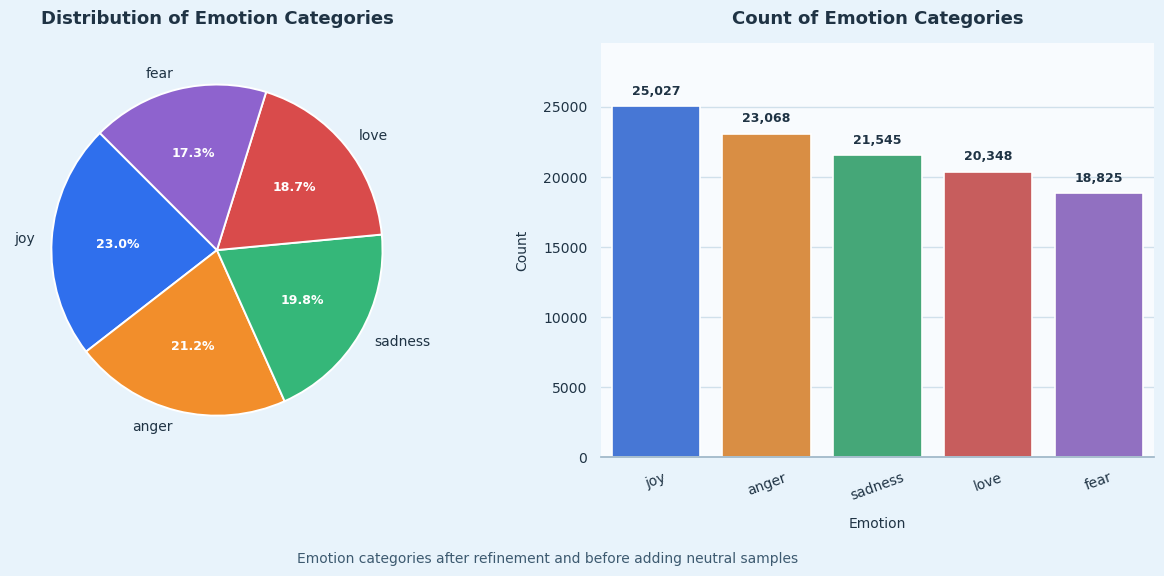

In [13]:
emotion_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear'
}

plot_dataset = ec_dataset.copy()
plot_dataset['label_name'] = plot_dataset['label'].map(emotion_map)
count = plot_dataset['label_name'].value_counts()

plot_distribution(
    count,
    left_title='Distribution of Emotion Categories',
    right_title='Count of Emotion Categories',
    x_label='Emotion',
    subtitle='Emotion categories after refinement and before adding neutral samples'
)

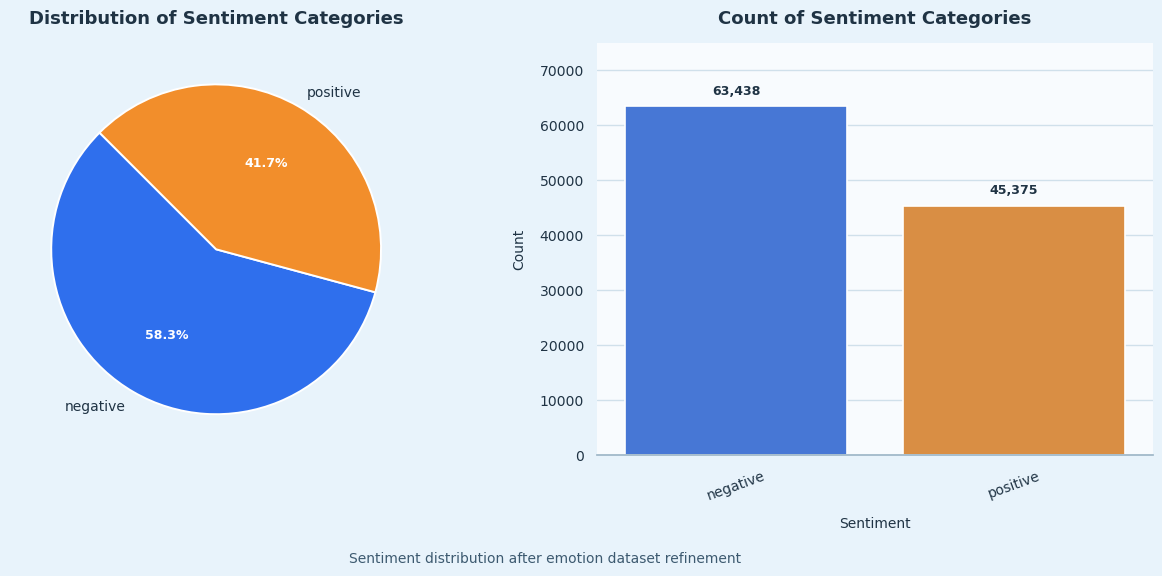

In [14]:
sentiment_map = {
    0: 'negative',
    1: 'positive'
}
sentiment_order = ['negative', 'positive']

plot_dataset = ec_dataset.copy()
plot_dataset['sentiment_name'] = plot_dataset['sentiment'].map(sentiment_map)
count = plot_dataset['sentiment_name'].value_counts().reindex(sentiment_order, fill_value=0)

plot_distribution(
    count,
    left_title='Distribution of Sentiment Categories',
    right_title='Count of Sentiment Categories',
    x_label='Sentiment',
    subtitle='Sentiment distribution after emotion dataset refinement'
)

In [15]:
# Specify a different encoding to read the CSV file
neutral = pd.read_csv('Twitter_Data.csv')

In [16]:
neutral.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [17]:
print(neutral['category'].value_counts())

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64


In [18]:
# Filter the DataFrame to keep only rows where category is neutral (0.0)
neutral['category'] = pd.to_numeric(neutral['category'], errors='coerce')
neutral_only = neutral.loc[neutral['category'] == 0.0, ['clean_text', 'category']].copy()

# Display the filtered DataFrame to confirm
print(neutral_only.head())
print("Number of neutral records before cleaning:", neutral_only.shape[0])


                                           clean_text  category
1   talk all the nonsense and continue all the dra...       0.0
5            kiya tho refresh maarkefir comment karo        0.0
6   surat women perform yagna seeks divine grace f...       0.0
7   this comes from cabinet which has scholars lik...       0.0
13  one vote can make all the difference anil kapo...       0.0
Number of neutral records before cleaning: 55213


In [19]:
neutral_only.head(20)

,clean_text,category
1,talk all the nonsense and continue all the dra...,0.0
5,kiya tho refresh maarkefir comment karo,0.0
6,surat women perform yagna seeks divine grace f...,0.0
7,this comes from cabinet which has scholars lik...,0.0
13,one vote can make all the difference anil kapo...,0.0
14,one vote can make all the difference anil kapo...,0.0
16,vote modi who has not created jobs,0.0
17,through our vote ensure govt need and deserve ...,0.0
22,crush jaws those who shoutmodimodi says jds ml...,0.0
26,has already taken notice and ordered probe now...,0.0


In [20]:
# Rename columns to match the emotion classification dataset format
neutral_only = neutral_only.rename(columns={'clean_text': 'text', 'category': 'sentiment'})

# Display the cleaned dataset to verify
print(neutral_only.head())


                                                 text  sentiment
1   talk all the nonsense and continue all the dra...        0.0
5            kiya tho refresh maarkefir comment karo         0.0
6   surat women perform yagna seeks divine grace f...        0.0
7   this comes from cabinet which has scholars lik...        0.0
13  one vote can make all the difference anil kapo...        0.0


In [21]:
neutral_only.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55213 entries, 1 to 162978
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   text       55211 non-null  object 
 1   sentiment  55213 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.3+ MB


In [22]:
# Drop rows where 'text' column is null
neutral_only = neutral_only.dropna(subset=['text']).copy()

# Remove duplicate rows based on 'sentiment' and 'text' columns
neutral_only = neutral_only.drop_duplicates(subset=['sentiment', 'text']).copy()

# Display the cleaned dataset to verify
print(neutral_only.head())
print(f"Number of rows after cleaning: {neutral_only.shape[0]}")
neutral_only.info()


                                                 text  sentiment
1   talk all the nonsense and continue all the dra...        0.0
5            kiya tho refresh maarkefir comment karo         0.0
6   surat women perform yagna seeks divine grace f...        0.0
7   this comes from cabinet which has scholars lik...        0.0
13  one vote can make all the difference anil kapo...        0.0
Number of rows after cleaning: 55211
<class 'pandas.core.frame.DataFrame'>
Index: 55211 entries, 1 to 162978
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   text       55211 non-null  object 
 1   sentiment  55211 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.3+ MB


In [23]:
# Display the first five complete sentences in the 'text' column
for i, sentence in enumerate(neutral_only['text'].head(50)):
    print(f"Sentence {i+1}: {sentence}")

Sentence 1: talk all the nonsense and continue all the drama will vote for modi 
Sentence 2: kiya tho refresh maarkefir comment karo 
Sentence 3: surat women perform yagna seeks divine grace for narendra modi become again

Sentence 4: this comes from cabinet which has scholars like modi smriti and hema time introspect
Sentence 5: one vote can make all the difference anil kapoor answers modis election 2019 clarion call extends support his vote kar campaign 
Sentence 6: one vote can make all the difference anil kapoor answers modis election 2019 clarion call extends support his campaign 
Sentence 7: vote modi who has not created jobs
Sentence 8: through our vote ensure govt need and deserve anupam kher responds modis appeal for the 2019 elections 
Sentence 9: crush jaws those who shoutmodimodi says jds mla this inciting murder
Sentence 10: has already taken notice and ordered probe now time for modi take notice muslim family being harassed beaten recently extremist hindus and was suggest

In [24]:
# Counting occurrences of the word "modi" in the 'text' column of neutral_only
modi_count = neutral_only['text'].str.contains('modi', case=False, na=False).sum()
print(modi_count)

49365


In [25]:
# Remove occurrences of the word "modi" (case-insensitive) in the 'text' column
neutral_only = neutral_only.copy()
neutral_only['text'] = neutral_only['text'].str.replace(r'\bmodi\b', '', case=False, regex=True)

# Remove rows that become empty after cleaning text
neutral_only['text'] = neutral_only['text'].str.strip()
neutral_only = neutral_only[neutral_only['text'].str.len() > 0].copy()

# Display the first few rows to verify
print(neutral_only.head())
print("Neutral records after removing 'modi' and empty text:", len(neutral_only))


                                                 text  sentiment
1   talk all the nonsense and continue all the dra...        0.0
5             kiya tho refresh maarkefir comment karo        0.0
6   surat women perform yagna seeks divine grace f...        0.0
7   this comes from cabinet which has scholars lik...        0.0
13  one vote can make all the difference anil kapo...        0.0
Neutral records after removing 'modi' and empty text: 55206


In [26]:
# Keep a fixed number of neutral samples so the final dataset size matches the reported dataset size.
neutral_target_count = 22082

if len(neutral_only) < neutral_target_count:
    raise ValueError("Not enough neutral samples to build the final dataset.")

neutral_only_reduced = neutral_only.sample(n=neutral_target_count, random_state=42).copy()
neutral_only_reduced.reset_index(drop=True, inplace=True)

# Display the first few rows to verify
print(neutral_only_reduced.head())
print(f"Original neutral size: {len(neutral_only)}, Selected neutral size: {len(neutral_only_reduced)}")

                                                text  sentiment
0                     please read this she pro trump        0.0
1            likely address poll rallies maharashtra        0.0
2  let’ all start thread saffron colour our daily...        0.0
3  balakot strike happens its not  and its the so...        0.0
4  everytime congress any congress spokesperson a...        0.0
Original neutral size: 55206, Selected neutral size: 22082


In [27]:
# In the final dataset:
# sentiment = 2 means neutral sentiment
# label = 5 means neutral emotion class
neutral_only_reduced['sentiment'] = 2
neutral_only_reduced.insert(1, 'label', 5)

# Make sure the column order matches the emotion classification dataset
neutral_only_reduced = neutral_only_reduced[['text', 'label', 'sentiment']]

# Display the first few rows and verify the real neutral count
print(neutral_only_reduced.head())
print("Neutral rows prepared for emotion classification dataset:", len(neutral_only_reduced))
print(neutral_only_reduced['label'].value_counts())


                                                text  label  sentiment
0                     please read this she pro trump      5          2
1            likely address poll rallies maharashtra      5          2
2  let’ all start thread saffron colour our daily...      5          2
3  balakot strike happens its not  and its the so...      5          2
4  everytime congress any congress spokesperson a...      5          2
Neutral rows prepared for emotion classification dataset: 22082
label
5    22082
Name: count, dtype: int64


In [28]:
final = pd.read_csv('updated_ec_dataset.csv')
print(final.head())

                                                text  label  sentiment
0                      i do when i feel dissatisfied      3          0
1         im feeling a little overwhelmed once again      4          0
2  i feel a lot of affection for you that is long...      2          1
3                            i feel jaded and insane      0          0
4               i feel vulnerable writing about love      4          0


In [29]:
final.head()

,text,label,sentiment
0,i do when i feel dissatisfied,3,0
1,im feeling a little overwhelmed once again,4,0
2,i feel a lot of affection for you that is long...,2,1
3,i feel jaded and insane,0,0
4,i feel vulnerable writing about love,4,0


In [30]:
final.head()
print(final['label'].value_counts())

label
1    25027
3    23068
0    21545
2    20348
4    18825
Name: count, dtype: int64


In [31]:
# Combine the original processed emotion dataset with the added neutral data
combined_dataset = pd.concat([final, neutral_only_reduced], ignore_index=True)

# Shuffle the combined dataset
combined_dataset = combined_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the first few rows to verify
print(combined_dataset.head())

# Important validation: neutral must really exist in the data, not only in the plot label
neutral_count = (combined_dataset['label'] == 5).sum()
print("Real neutral rows in combined_dataset:", neutral_count)
if neutral_count == 0:
    raise ValueError("No neutral rows found in combined_dataset. Please rerun the neutral extraction cells before plotting.")


                                                text  label  sentiment
0  i have a reason for feeling homesick at least ...      0          0
1  i feel enraged that my kids future in this com...      3          0
2              i feel i earnt it this week as i lost      0          0
3  im feeling anxious all im really trying to do ...      4          0
4  i remember saying wow kids i m so sorry it kin...      0          0
Real neutral rows in combined_dataset: 22082


In [32]:
print("Emotion label counts in combined_dataset:")
print(combined_dataset['label'].value_counts().sort_index())

print("Sentiment label counts in combined_dataset:")
print(combined_dataset['sentiment'].value_counts().sort_index())


Emotion label counts in combined_dataset:
label
0    21545
1    25027
2    20348
3    23068
4    18825
5    22082
Name: count, dtype: int64
Sentiment label counts in combined_dataset:
sentiment
0    63438
1    45375
2    22082
Name: count, dtype: int64


In [33]:
combined_dataset.to_csv('final_ec_dataset.csv', index=False)

print("The updated dataset has been saved as 'final_ec_dataset.csv'.")

The updated dataset has been saved as 'final_ec_dataset.csv'.


In [34]:
# Load the dataset
final_ec_dataset = pd.read_csv('final_ec_dataset.csv')

# Validate that neutral data really exists before splitting
neutral_count = (final_ec_dataset['label'] == 5).sum()
print("Real neutral rows in final_ec_dataset.csv:", neutral_count)
if neutral_count == 0:
    raise ValueError("final_ec_dataset.csv does not contain label=5 neutral rows. Rerun the concat/save cells above.")

# Split the dataset into training and testing sets (80% training, 20% testing)
# stratify keeps every class, including neutral, represented in both train and test sets.
train_data, test_data = train_test_split(
    final_ec_dataset,
    test_size=0.2,
    random_state=42,
    stratify=final_ec_dataset['label']
)

# Save the training and testing sets to separate CSV files
train_data.to_csv('final_ec_dataset_train.csv', index=False)
test_data.to_csv('final_ec_dataset_test.csv', index=False)

print("Training and testing datasets have been saved as 'final_ec_dataset_train.csv' and 'final_ec_dataset_test.csv'.")
print("Training label counts:")
print(train_data['label'].value_counts().sort_index())
print("Testing label counts:")
print(test_data['label'].value_counts().sort_index())


Real neutral rows in final_ec_dataset.csv: 22082


Training and testing datasets have been saved as 'final_ec_dataset_train.csv' and 'final_ec_dataset_test.csv'.
Training label counts:
label
0    17236
1    20022
2    16278
3    18454
4    15060
5    17666
Name: count, dtype: int64
Testing label counts:
label
0    4309
1    5005
2    4070
3    4614
4    3765
5    4416
Name: count, dtype: int64


In [35]:
final_ec_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130895 entries, 0 to 130894
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   text       130895 non-null  object
 1   label      130895 non-null  int64 
 2   sentiment  130895 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.0+ MB


Raw numeric sentiment counts in final_ec_dataset_train.csv:
sentiment
0    50750
1    36300
2    17666
Name: count, dtype: int64
Named sentiment counts used for plotting:
sentiment_name
negative    50750
neutral     17666
positive    36300
Name: count, dtype: int64


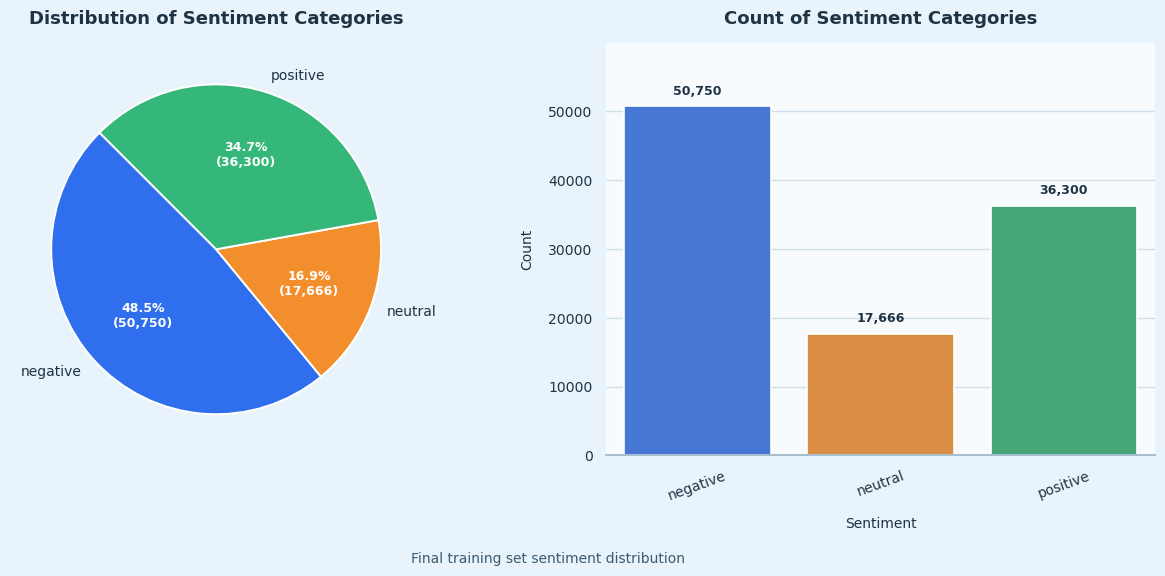

In [36]:
final_ec_dataset = pd.read_csv('final_ec_dataset_train.csv')
final_ec_dataset['sentiment'] = pd.to_numeric(final_ec_dataset['sentiment'], errors='coerce')

sentiment_map = {
    0: 'negative',
    1: 'positive',
    2: 'neutral'
}
sentiment_order = ['negative', 'neutral', 'positive']

raw_sentiment_count = final_ec_dataset['sentiment'].value_counts().sort_index()
print('Raw numeric sentiment counts in final_ec_dataset_train.csv:')
print(raw_sentiment_count)

neutral_count = raw_sentiment_count.get(2, 0)
if neutral_count == 0:
    raise ValueError(
        'final_ec_dataset_train.csv has no real sentiment=2 neutral rows. '
        'Rerun the cells that create neutral_only_reduced, combined_dataset, '
        'final_ec_dataset.csv, and final_ec_dataset_train.csv.'
    )

final_ec_dataset['sentiment_name'] = final_ec_dataset['sentiment'].map(sentiment_map)

unmapped = final_ec_dataset.loc[
    final_ec_dataset['sentiment_name'].isna(),
    'sentiment'
].value_counts(dropna=False)

if len(unmapped) > 0:
    print('Unmapped sentiment values:')
    print(unmapped)

count = (
    final_ec_dataset['sentiment_name']
    .value_counts()
    .reindex(sentiment_order, fill_value=0)
)

print('Named sentiment counts used for plotting:')
print(count)

plot_distribution(
    count,
    left_title='Distribution of Sentiment Categories',
    right_title='Count of Sentiment Categories',
    x_label='Sentiment',
    subtitle='Final training set sentiment distribution',
    show_pie_counts=True
)

Raw numeric emotion-label counts in final_ec_dataset_train.csv:
label
0    17236
1    20022
2    16278
3    18454
4    15060
5    17666
Name: count, dtype: int64
Named emotion-label counts used for plotting:
label_name
sadness    17236
joy        20022
love       16278
anger      18454
fear       15060
neutral    17666
Name: count, dtype: int32


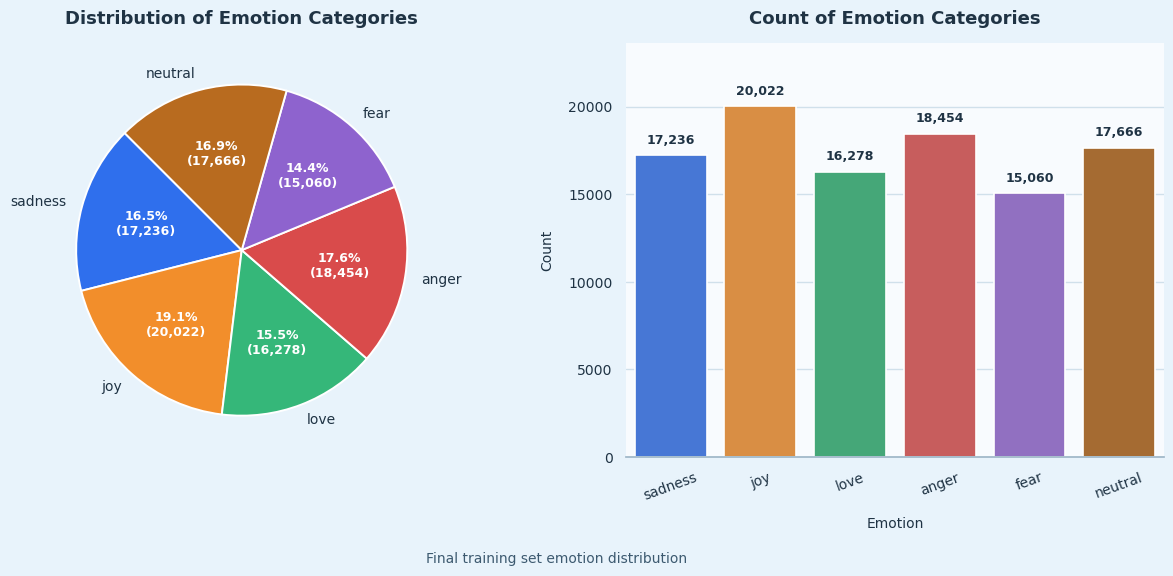

In [37]:
final_ec_dataset = pd.read_csv('final_ec_dataset_train.csv')

label_map = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'neutral'
}

label_order = ['sadness', 'joy', 'love', 'anger', 'fear', 'neutral']

raw_label_count = final_ec_dataset['label'].value_counts().sort_index()
print('Raw numeric emotion-label counts in final_ec_dataset_train.csv:')
print(raw_label_count)

if 5 not in raw_label_count.index or raw_label_count.loc[5] == 0:
    raise ValueError(
        'final_ec_dataset_train.csv has no real label=5 neutral rows. '
        'Rerun the cells that create neutral_only_reduced, combined_dataset, '
        'final_ec_dataset.csv, and final_ec_dataset_train.csv.'
    )

final_ec_dataset['label_name'] = final_ec_dataset['label'].map(label_map)

count = (
    final_ec_dataset['label_name']
    .value_counts()
    .reindex(label_order, fill_value=0)
    .astype(int)
)

print('Named emotion-label counts used for plotting:')
print(count)

plot_distribution(
    count,
    left_title='Distribution of Emotion Categories',
    right_title='Count of Emotion Categories',
    x_label='Emotion',
    subtitle='Final training set emotion distribution',
    show_pie_counts=True
)

# 5. Conclusion
Eventually, the final dataset contains 130,895 samples in total. This number represents the full dataset before splitting, not the training set alone. After an 80/20 stratified split by emotion label, it has 104,716 training samples and 26,179 testing samples. The emotion classes are much more balanced than the original dataset. The smaller love class is increased through synonym replacement, while the added neutral samples provide both label = 5 for neutral emotion and sentiment = 2 for neutral sentiment.

In [38]:
SD_dataset = pd.read_csv(r"sarcasm_dataset.csv")
print(SD_dataset.head())

if WordCloud is None:
    print("WordCloud is not installed in this environment. Install the wordcloud package to generate this figure.")
else:
    text_data = " ".join(SD_dataset["headline"].astype(str))
    wordcloud = WordCloud(width=1000, height=480, background_color="white", colormap="viridis").generate(text_data)

    plt.figure(figsize=(10.5, 5.2), facecolor=PLOT_BACKGROUND)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Sarcasm Detection Dataset", fontsize=16, fontweight="bold", color=TEXT_COLOR, pad=12)
    plt.tight_layout()
    plt.show()

   Unnamed: 0  is_sarcastic                                           headline
0           0             1  thirtysomething scientists unveil doomsday clo...
1           1             0  dem rep. totally nails why congress is falling...
2           2             0  eat your veggies: 9 deliciously different recipes
3           3             1  inclement weather prevents liar from getting t...
4           4             1  mother comes pretty close to using word 'strea...
WordCloud is not installed in this environment. Install the wordcloud package to generate this figure.


In [39]:
print(SD_dataset['is_sarcastic'].value_counts())

is_sarcastic
0    14985
1    13634
Name: count, dtype: int64
